In [489]:
#Package
import numpy as np
import networkx as nx
from scipy.stats import qmc
import EoN
from pathlib import Path
import pickle
from scipy.stats import qmc
from pathlib import Path
from tqdm import tqdm
from pathlib import Path
import csv
import pymc as pm 
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# PARAMETERS
N = 100000                  # network size
m = 10                      # Barabasi–Albert attachment parameter

tmax=80
n_timepoints=80
initial_samples =250   # initial Sobol samples #500
sigma = 0.15            # width of R0 target distribution
n_replicates=2  # replicates of parameter sets 

PARAM_RANGES = {
    'tau'  : (0.0005,0.024),  # Expected range: R₀ ∈ [0.12, 4.98] #   recovery rate
    'gamma': (0.007,0.5),
    'rho'  : (0.001,0.010),
}

PARAM_NAMES = ['tau', 'gamma', 'rho']
output_path = Path('epidemic_data_age_adaptive_sobol.pkl')

In [491]:
# import numpy as np
# import networkx as nx

# results_k_avg = []
# results_k2_avg = []
# results_ratio = []

# for i in range(10):
    
#     G = nx.barabasi_albert_graph(N, m)
    
#     degrees = np.array([d for _, d in G.degree()])
    
#     k_avg = degrees.mean()
#     k2_avg = (degrees**2).mean()
#     ratio = k2_avg / k_avg
    
#     results_k_avg.append(k_avg)
#     results_k2_avg.append(k2_avg)
#     results_ratio.append(ratio)

# # convert to arrays
# results_k_avg = np.array(results_k_avg)
# results_k2_avg = np.array(results_k2_avg)
# results_ratio = np.array(results_ratio)

# # means
# mean_k_avg = results_k_avg.mean()
# mean_k2_avg = results_k2_avg.mean()
# mean_ratio = results_ratio.mean()

# # standard errors
# se_k_avg = results_k_avg.std(ddof=1)/np.sqrt(len(results_k_avg))
# se_k2_avg = results_k2_avg.std(ddof=1)/np.sqrt(len(results_k2_avg))
# se_ratio = results_ratio.std(ddof=1)/np.sqrt(len(results_ratio))

# # 95% CI
# ci_k_avg = (mean_k_avg - 1.96*se_k_avg, mean_k_avg + 1.96*se_k_avg)
# ci_k2_avg = (mean_k2_avg - 1.96*se_k2_avg, mean_k2_avg + 1.96*se_k2_avg)
# ci_ratio = (mean_ratio - 1.96*se_ratio, mean_ratio + 1.96*se_ratio)

# print("Mean <k>:", mean_k_avg, "CI:", ci_k_avg)
# print("Mean <k^2>:", mean_k2_avg, "CI:", ci_k2_avg)
# print("Mean <k^2>/<k>:", mean_ratio, "CI:", ci_ratio)

In [492]:
# print(se_k2_avg)

In [493]:
#p=0.0001
# degrees_list = []
# for i in range(1000):
#     G = nx.erdos_renyi_graph(N, p)
#     degrees = np.array([d for _, d in G.degree()])
#     degrees_list.append(degrees)

# k_avg = np.array(degrees_list).mean()
# k2_avg = (np.array(degrees_list)**2).mean()
# ratio = k2_avg / k_avg

# print( ratio)

In [494]:
#ratio=27.267136934467235 # calculated for 10000 graphs
ratio=34.0 # calculated for 100000 graphs
#ratio=2.0 # calculated for 100000 graphs


In [495]:
net_stats = {
    'k_avg': 9.9988,
    'k2_avg': 266.020,
    'ratio': ratio,
    'k_std': 1.5,
    'k_max': 20
}


In [496]:
# R0 COMPUTATION
def compute_R0(samples,ratio):
    """
    Compute epidemic reproduction number.

    R0 = (tau/gamma) * <k²>/<k>
    """

    tau = samples[:, 0]
    gamma = samples[:, 1]

    R0 = (tau/gamma) * ratio  

    return R0

In [497]:
# Using MCMC to sample from the target distribution  with Uniform distribution

#thinning    = int(mcmc_steps / initial_samples) 

with pm.Model() as model:
    
    # Priors: Uniform over plausible ranges
    tau   = pm.Uniform("tau", lower=PARAM_RANGES['tau'][0], upper=PARAM_RANGES['tau'][1])
    gamma = pm.Uniform("gamma", lower=PARAM_RANGES['gamma'][0], upper=PARAM_RANGES['gamma'][1])
    rho   = pm.Uniform("rho", lower=PARAM_RANGES['rho'][0], upper=PARAM_RANGES['rho'][1])

    # Compute R0 deterministically
    R0 = pm.Deterministic("R0", (tau / gamma) * ratio)
    
    # Target density: Gaussian around R0 ≈ 1
    logp = -0.5 * ((R0 - 1.0) / sigma) ** 2
    pm.Potential("R0_target", logp)
    
    # Sample with NUTS
   
    trace = pm.sample(
        draws=initial_samples,
        tune=2500, # thinning,
        chains=4,  # thus Total_sample=samples*chains
        cores=1,
        target_accept=0.95,
        random_seed=42
    )

# Convert trace to (n_samples, 3) array: tau, gamma, rho
posterior_samples = np.vstack([
    trace.posterior['tau'].values.flatten(),
    trace.posterior['gamma'].values.flatten(),
    trace.posterior['rho'].values.flatten()
]).T



Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [tau, gamma, rho]


Sampling 4 chains for 2_500 tune and 250 draw iterations (10_000 + 1_000 draws total) took 56 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [498]:
az.summary(trace, var_names=["tau", "gamma", "rho"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
tau,0.010,0.004,0.002,0.017,0.000,0.000,299.0,241.0,1.01
gamma,0.334,0.116,0.122,0.499,0.007,0.004,250.0,256.0,1.03
rho,0.005,0.003,0.001,0.010,0.000,0.000,320.0,414.0,1.01


In [499]:
# az.plot_forest(trace, var_names=["tau", "gamma", "rho"], hdi_prob=0.95)

| Metric          | Meaning                      |
| --------------- | ---------------------------- |
| mean            | Posterior mean estimate      |
| sd              | Posterior standard deviation |
| hdi_3%, hdi_97% | 94% Highest Density Interval |
| mcse_mean       | Monte Carlo error of mean    |
| mcse_sd         | Monte Carlo error of sd      |
| ess_bulk        | Effective sample size (bulk) |
| ess_tail        | Effective sample size (tail) |
| r_hat           | Convergence diagnostic       |


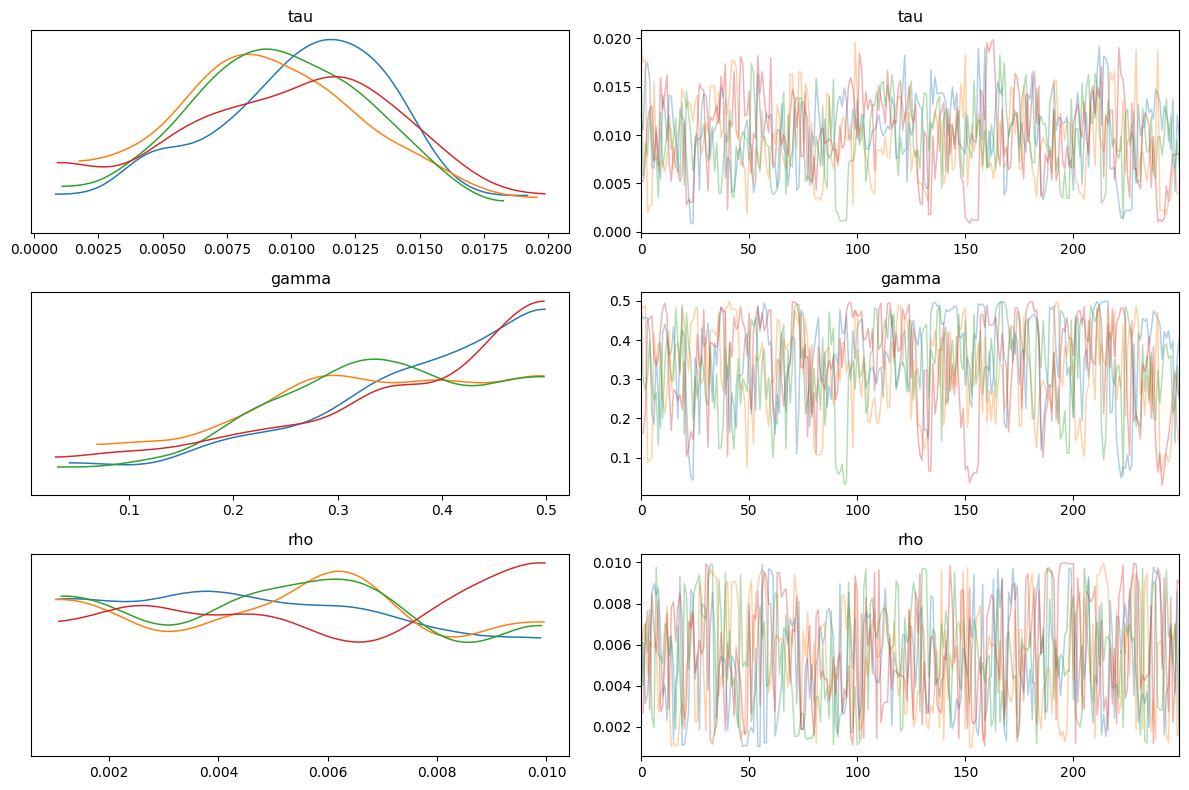

In [500]:
az.plot_trace(
    trace,
    var_names=["tau", "gamma", "rho"],
    compact=False,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

In [501]:
# #SOBOL INITIALIZATION FOR MCMC
# sampler = qmc.Sobol(d=3, scramble=True)

# lower = [v[0] for v in PARAM_RANGES.values()]
# upper = [v[1] for v in PARAM_RANGES.values()]

# sobol_points = qmc.scale(sampler.random(2), lower, upper)  # 5for 5

# initvals = [
#     {"tau": sobol_points[0,0], "gamma": sobol_points[0,1], "rho": sobol_points[0,2]}, # initial values for 2 chains
#     {"tau": sobol_points[1,0], "gamma": sobol_points[1,1], "rho": sobol_points[1,2]}
# ]

# # initvals= [
# #     {"tau": sobol_points[i,0], "gamma": sobol_points[i,1], "rho": sobol_points[i,2]}
# #     for i in range(5)  # now matches number of chains
# # ]

# # MCMC MODEL

# with pm.Model() as model:

#     tau = pm.Uniform("tau",
#                      lower=PARAM_RANGES['tau'][0],
#                      upper=PARAM_RANGES['tau'][1])

#     gamma = pm.Uniform("gamma",
#                        lower=PARAM_RANGES['gamma'][0],
#                        upper=PARAM_RANGES['gamma'][1])

#     rho = pm.Uniform("rho",
#                      lower=PARAM_RANGES['rho'][0],
#                      upper=PARAM_RANGES['rho'][1])

#     R0 = pm.Deterministic("R0", (tau/gamma) * ratio)

#     logp = -0.5 * ((R0 - 1.0)/sigma)**2

#     pm.Potential("target_density", logp)

#     trace = pm.sample(
#         draws=initial_samples,
#         tune=2000,
#         chains=2,
#         cores=1,
#         target_accept=0.95,
#         initvals=initvals,
#         random_seed=42
#     )


# # EXTRACT POSTERIOR SAMPLES

# posterior_samples = np.vstack([
#     trace.posterior['tau'].values.flatten(),
#     trace.posterior['gamma'].values.flatten(),
#     trace.posterior['rho'].values.flatten()
# ]).T

# print("Posterior samples shape:", posterior_samples.shape)

In [502]:
#posterior sample dimensions 
print(posterior_samples.shape) #1000,3

(1000, 3)


In [503]:
# #  Define SIR replicates


# def run_sir_replicates(G, tau, gamma, rho, n_replicates=n_replicates, tmax=tmax, n_timepoints=n_timepoints):
#     t_fixed = np.linspace(0, tmax, n_timepoints)
#     S_runs, I_runs, R_runs = [], [], []

#     for _ in range(n_replicates):
#         t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax=tmax)
#         S_runs.append(np.interp(t_fixed, t, S))
#         I_runs.append(np.interp(t_fixed, t, I))
#         R_runs.append(np.interp(t_fixed, t, R))

#     return {
#         't': t_fixed,
#         'S': np.array(S_runs).mean(axis=0),
#         'I': np.array(I_runs).mean(axis=0),
#         'R': np.array(R_runs).mean(axis=0),
#         'S_std': np.array(S_runs).std(axis=0),
#         'I_std': np.array(I_runs).std(axis=0),
#         'R_std': np.array(R_runs).std(axis=0),
#         'n_replicates': n_replicates
#     }


In [504]:
# def run_sir_full_uncertainty(G, posterior_samples, n_trajectory_replicates=n_replicates, 
#                               tmax=tmax, n_timepoints=n_timepoints):
#     t_fixed = np.linspace(0, tmax, n_timepoints)
#     all_S, all_I, all_R = [], [], []

#     for tau, gamma, rho in tqdm(posterior_samples, desc="Posterior + stochastic replicates"):
#         for _ in range(n_trajectory_replicates):
#             t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax=tmax)
#             all_S.append(np.interp(t_fixed, t, S))
#             all_I.append(np.interp(t_fixed, t, I))
#             all_R.append(np.interp(t_fixed, t, R))

#     all_S = np.array(all_S)   # (n_samples * n_replicates, T)
#     all_I = np.array(all_I)
#     all_R = np.array(all_R)

#     return {
#         't'    : t_fixed,
#         'all_I': all_I,          # keep raw matrix for percentile plotting
#         'all_S': all_S,
#         'all_R': all_R,
#         'I_mean': all_I.mean(axis=0),
#         'S_mean': all_S.mean(axis=0),
#         'R_mean': all_R.mean(axis=0),
#         'I_p10' : np.percentile(all_I, 10, axis=0),
#         'I_p90' : np.percentile(all_I, 90, axis=0),
#         'I_p25' : np.percentile(all_I, 25, axis=0),
#         'I_p75' : np.percentile(all_I, 75, axis=0),
#     }


# def plot_sir_uncertainty(full_results, R0_threshold=1.0, graph_stats=None):
#     """
#     Plot mean ± percentile bands, split by epidemic outcome.
    
#     Splits trajectories into:
#         - extinction (final R < 1% of N): near-threshold or sub-critical
#         - outbreak   (final R ≥ 1% of N): super-critical
#     """
#     t      = full_results['t']
#     all_I  = full_results['all_I']
#     all_R  = full_results['all_R']
#     N      = all_R[:, 0].mean() + all_I[:, 0].mean() + \
#              (10000 - all_R[:, 0].mean() - all_I[:, 0].mean())  # fallback

#     # Split by final epidemic size
#     final_R      = all_R[:, -1]
#     extinct_mask = final_R < 0.01 * 10000
#     outbreak_mask= ~extinct_mask

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
#     fig.suptitle("SIR Epidemic Trajectories — Posterior + Stochastic Uncertainty", 
#                  fontsize=13, fontweight='bold')

#     for ax, mask, label, color in [
#         (axes[0], extinct_mask,  "Extinction / near-threshold", "steelblue"),
#         (axes[1], outbreak_mask, "Outbreak",                    "firebrick"),
#     ]:
#         subset = all_I[mask]
#         n      = mask.sum()

#         if n == 0:
#             ax.set_title(f"{label}\n(no trajectories)")
#             continue

#         mean_I = subset.mean(axis=0)
#         p10    = np.percentile(subset, 10, axis=0)
#         p25    = np.percentile(subset, 25, axis=0)
#         p75    = np.percentile(subset, 75, axis=0)
#         p90    = np.percentile(subset, 90, axis=0)

#         ax.fill_between(t, p10, p90, color=color, alpha=0.15, label='10–90th pct')
#         ax.fill_between(t, p25, p75, color=color, alpha=0.30, label='25–75th pct')
#         ax.plot(t, mean_I, color=color, linewidth=2, label='Mean I(t)')

#         ax.set_xlabel("Time")
#         ax.set_ylabel("Number infectious")
#         ax.set_title(f"{label}  (n={n})")
#         ax.set_ylim(bottom=0)          # enforce non-negativity
#         ax.legend(fontsize=9)
#         ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.savefig("trajectories_split.png", dpi=200, bbox_inches='tight')
#     plt.show()


# # --- run ---
# G            = nx.barabasi_albert_graph(N, m)
# full_results = run_sir_full_uncertainty(G, posterior_samples, 
#                                          n_trajectory_replicates=n_replicates)
# plot_sir_uncertainty(full_results)

The uncertainty plot (posterior + stochastic) is the primary evidence that the emulator is worth building in the first place. It shows two sources of uncertainty simultaneously — parameter uncertainty (which τ, γ, ρ are the true values?) and stochastic uncertainty (given fixed parameters, how variable is the epidemic on a finite network?). It reveals that the posterior is bimodal — some parameter combinations produce epidemics that die out quickly (extinction regime, R₀ < 1 or near-threshold stochastic fadeout) and others produce genuine outbreaks (R₀ > 1).
Justifies the near-R₀=1 concentration — the threshold boundary is where prediction is hardest and where the two regimes mix, so that's where your adaptive samples should go

 epidemic uncertainty is large, bimodal, and concentrated near a threshold

 Left panel — extinction / near-threshold (n=4,684)
The IQR band (25–75th pct) is extremely tight and the mean decays to zero by t≈25. This says: when parameters fall below or near the epidemic threshold, the outcome is highly predictable — the epidemic burns out quickly and stochastic variation between runs is small. The wide 10–90th band at t=0–5 reflects the seed randomness (rho draws a slightly different initial infected count), not genuine epidemic uncertainty. After t=25 there is essentially nothing left to predict. This is the regime where your emulator will get artificially high R² — near-zero trajectories have near-zero variance, so even a model that outputs a flat zero line scores well.

Right panel — outbreak (n=7,816)
Far more interesting. Three things stand out:
The IQR is wide throughout the peak. At t≈10 the 25–75th band spans roughly 20–70 infectious — a 3.5× range. This is genuine stochastic uncertainty on a finite BA network: hubs may or may not be infected early, and that single event changes the entire trajectory. This is exactly the heterogeneous network effect your dissertation is about — a homogeneous mixing model would show a much tighter band.

The mean peak (~55) sits well below the 90th percentile (~140). The distribution is right-skewed, confirming that "bad" outcomes (hub-seeded large outbreaks) pull the tail up while most replicates produce moderate epidemics.

Both regimes converge to zero by t≈75. This validates your loss_I_terminal prior — at t=200, I(t)≈0 is a true physical constraint, not just a modelling assumption.


Contained in the all sims
| Key        | Description                                                                                                                                                                 |
| ---------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `'t'`      | A 1D NumPy array of time points (`t_fixed`), length `n_timepoints`. Same for all simulations because we interpolate trajectories onto a fixed grid.                         |
| `'S_mean'` | Mean susceptible trajectory at each time point, averaged **over all posterior parameter sets and their replicates**. Shape: `(n_timepoints,)`.                              |
| `'I_mean'` | Mean infected trajectory at each time point, same averaging. Shape: `(n_timepoints,)`.                                                                                      |
| `'R_mean'` | Mean recovered trajectory at each time point, same averaging. Shape: `(n_timepoints,)`.                                                                                     |
| `'S_std'`  | Standard deviation of susceptible trajectories at each time point. Captures **both parameter uncertainty and stochastic trajectory variability**. Shape: `(n_timepoints,)`. |
| `'I_std'`  | Standard deviation of infected trajectories. Same as above.                                                                                                                 |
| `'R_std'`  | Standard deviation of recovered trajectories. Same as above.                                                                                                                |


In [505]:
# def run_batch(G, posterior_samples, n_replicates=n_replicates, tmax=tmax, n_timepoints=n_timepoints):
#     """
#     Run SIR simulations for each parameter set, storing every replicate
#     as an individual simulation record compatible with build_dataset.
    
#     Each record:
#         sim['params']  → {'tau', 'gamma', 'rho'}
#         sim['output']  → {'t', 'S', 'I', 'R'}  (numpy arrays, length n_timepoints)
#     """
#     t_fixed = np.linspace(0, tmax, n_timepoints)
#     all_sims = []

#     for tau, gamma, rho in tqdm(posterior_samples, desc="Running batch simulations"):
#         for rep in range(n_replicates):
#             t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax=tmax)

#             all_sims.append({
#                 'params': {
#                     'tau'  : float(tau),
#                     'gamma': float(gamma),
#                     'rho'  : float(rho),
#                 },
#                 'output': {
#                     't': t_fixed,
#                     'S': np.interp(t_fixed, t, S),
#                     'I': np.interp(t_fixed, t, I),
#                     'R': np.interp(t_fixed, t, R),
#                 },
#                 'replicate_id': rep,
#             })

#     print(f"Generated {len(all_sims)} simulations "
#           f"({len(posterior_samples)} param sets × {n_replicates} replicates)")
#     return all_sims


# # build_dataset — two fixes from your version:
# # 1. n_timepoints added to metadata (needed by utils_SIR.create_dataloaders)
# # 2. ratio read from net_stats directly (not passed separately)

# def build_dataset(all_sims, G, net_stats):
#     # infer n_timepoints from first simulation
#     n_timepoints = len(all_sims[0]['output']['t'])

#     dataset = {
#         'simulations': all_sims,
#         'network': {
#             'type' : 'barabasi_albert',
#             'N'    : G.number_of_nodes(),
#             'm'    : m,
#             'ratio': net_stats['ratio'],
#             'graph': G,
#         },
#         'metadata': {
#             'n_samples'         : len(all_sims),
#             'n_replicates'      : n_replicates,
#             'n_timepoints'      : n_timepoints,   # ← critical for utils_SIR
#             'param_ranges'      : PARAM_RANGES,
#             'R0_formula'        : 'R0 = (tau/gamma) * <k²>/<k>',
#             'sampling_strategy' : 'MCMC',
#         }
#     }
#     return dataset


# # save_csv — one fix: I and R are numpy arrays, so .max() works,
# # but argmax needs care when the epidemic goes extinct immediately

# def save_dataset(dataset, filepath='epidemic_data_age_adaptive_sobol.pkl'):
#     with open(filepath, 'wb') as f:
#         pickle.dump(dataset, f, protocol=pickle.HIGHEST_PROTOCOL)
#     print(f"Dataset saved → {filepath}  ({len(dataset['simulations'])} sims)")

# def plot_sir_uncertainty(full_results, R0_threshold=1.0, graph_stats=None):
#     """
#     Plot mean ± percentile bands, split by epidemic outcome.
    
#     Splits trajectories into:
#         - extinction (final R < 1% of N): near-threshold or sub-critical
#         - outbreak   (final R ≥ 1% of N): super-critical
#     """
#     t      = full_results['t']
#     all_I  = full_results['all_I']
#     all_R  = full_results['all_R']
#     N      = all_R[:, 0].mean() + all_I[:, 0].mean() + \
#              (10000 - all_R[:, 0].mean() - all_I[:, 0].mean())  # fallback

#     # Split by final epidemic size
#     final_R      = all_R[:, -1]
#     extinct_mask = final_R < 0.01 * 10000
#     outbreak_mask= ~extinct_mask

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
#     fig.suptitle("SIR Epidemic Trajectories — Posterior + Stochastic Uncertainty", 
#                  fontsize=13, fontweight='bold')

#     for ax, mask, label, color in [
#         (axes[0], extinct_mask,  "Extinction / near-threshold", "steelblue"),
#         (axes[1], outbreak_mask, "Outbreak",                    "firebrick"),
#     ]:
#         subset = all_I[mask]
#         n      = mask.sum()

#         if n == 0:
#             ax.set_title(f"{label}\n(no trajectories)")
#             continue

#         mean_I = subset.mean(axis=0)
#         p10    = np.percentile(subset, 10, axis=0)
#         p25    = np.percentile(subset, 25, axis=0)
#         p75    = np.percentile(subset, 75, axis=0)
#         p90    = np.percentile(subset, 90, axis=0)

#         ax.fill_between(t, p10, p90, color=color, alpha=0.15, label='10–90th pct')
#         ax.fill_between(t, p25, p75, color=color, alpha=0.30, label='25–75th pct')
#         ax.plot(t, mean_I, color=color, linewidth=2, label='Mean I(t)')

#         ax.set_xlabel("Time")
#         ax.set_ylabel("Number infectious")
#         ax.set_title(f"{label}  (n={n})")
#         ax.set_ylim(bottom=0)          # enforce non-negativity
#         ax.legend(fontsize=9)
#         ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.savefig("trajectories_split.png", dpi=200, bbox_inches='tight')
#     plt.show()


# def save_csv(dataset, filepath='epidemic_data_age_adaptive_sobol.csv'):
#     sims  = dataset['simulations']
#     ratio = dataset['network']['ratio']
#     fields = ['sim_id', 'replicate_id', 'tau', 'gamma', 'rho',
#               'R0', 'peak_I', 'peak_time', 'final_R', 'attack_rate', 'near_threshold']

#     with open(filepath, 'w', newline='') as f:
#         writer = csv.DictWriter(f, fieldnames=fields)
#         writer.writeheader()

#         for sim_id, sim in enumerate(sims):
#             tau   = sim['params']['tau']
#             gamma = sim['params']['gamma']
#             rho   = sim['params']['rho']
#             R0    = (tau / gamma) * ratio

#             I      = sim['output']['I']
#             R      = sim['output']['R']
#             t_grid = sim['output']['t']

#             peak_idx  = int(I.argmax())

#             writer.writerow({
#                 'sim_id'        : sim_id,
#                 'replicate_id'  : sim.get('replicate_id', 0),
#                 'tau'           : tau,
#                 'gamma'         : gamma,
#                 'rho'           : rho,
#                 'R0'            : round(R0, 4),
#                 'peak_I'        : float(I[peak_idx]),
#                 'peak_time'     : float(t_grid[peak_idx]),
#                 'final_R'       : float(R[-1]),
#                 'attack_rate'   : float(R[-1] / G.number_of_nodes()),
#                 'near_threshold': int(abs(R0 - 1) < 0.2),
#             })

#     print(f"CSV saved to {filepath}  ({len(sims)} rows)")


# # --- entry point ---
# G        = nx.barabasi_albert_graph(N, m)

# all_sims  = run_batch(G, posterior_samples, n_replicates=n_replicates)
# dataset   = build_dataset(all_sims, G, net_stats)

# def summarise_for_plot(dataset):
#     """Aggregate individual sim records into mean/percentile arrays for plotting."""
#     sims    = dataset['simulations']
#     t_fixed = sims[0]['output']['t']

#     all_I = np.array([s['output']['I'] for s in sims])
#     all_S = np.array([s['output']['S'] for s in sims])
#     all_R = np.array([s['output']['R'] for s in sims])

#     return {
#         't'    : t_fixed,
#         'all_I': all_I,
#         'all_S': all_S,
#         'all_R': all_R,
#         'I_mean': all_I.mean(axis=0),
#         'I_p10' : np.percentile(all_I, 10, axis=0),
#         'I_p25' : np.percentile(all_I, 25, axis=0),
#         'I_p75' : np.percentile(all_I, 75, axis=0),
#         'I_p90' : np.percentile(all_I, 90, axis=0),
#     }

# # --- now safe to call ---
# full_results = summarise_for_plot(dataset)
# plot_sir_uncertainty(full_results)

# save_dataset(dataset, filepath='epidemic_data_age_adaptive_sobol.pkl')
# save_csv(dataset, filepath='epidemic_data_age_adaptive_sobol.csv')


Running batch simulations: 100%|██████████| 1000/1000 [04:56<00:00,  3.37it/s]


Generated 2000 simulations (1000 param sets × 2 replicates)


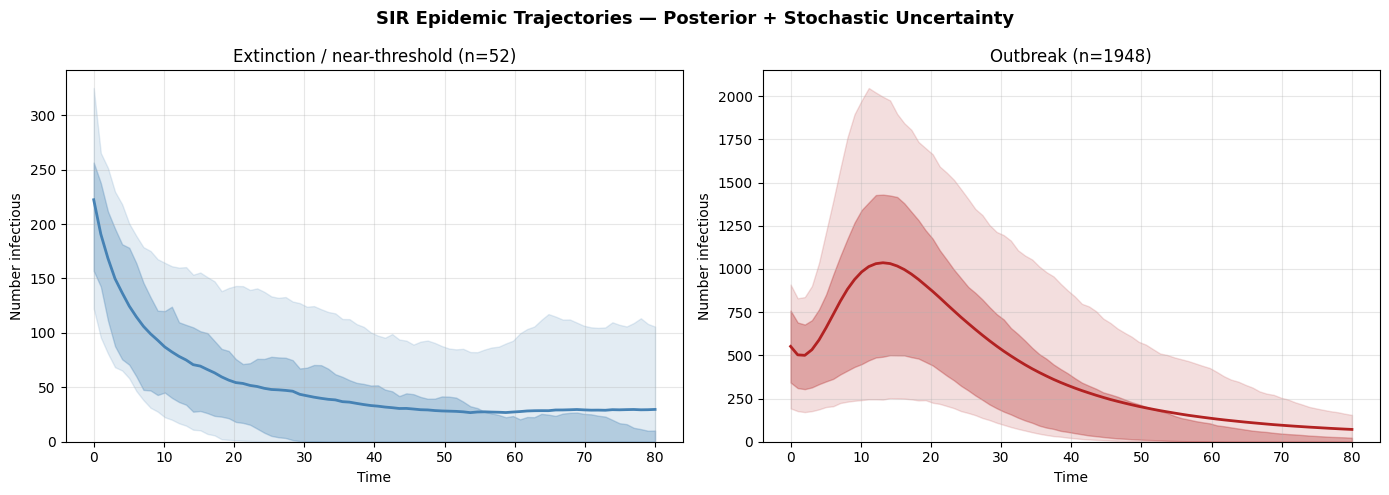

Dataset saved → epidemic_data_age_adaptive_sobol.pkl (2000 sims)
CSV saved to epidemic_data_age_adaptive_sobol.csv (2000 rows)


In [506]:


def run_batch(G, posterior_samples, n_replicates, tmax, n_timepoints, seed=None):
    
    if seed is not None:
        np.random.seed(seed)

    t_fixed = np.linspace(0, tmax, n_timepoints)
    all_sims = []

    for tau, gamma, rho in tqdm(posterior_samples, desc="Running batch simulations"):

        for rep in range(n_replicates):

            t, S, I, R = EoN.fast_SIR(G, tau, gamma, rho=rho, tmax=tmax)

            all_sims.append({
                'params': {
                    'tau': float(tau),
                    'gamma': float(gamma),
                    'rho': float(rho),
                },
                'output': {
                    't': t_fixed,
                    'S': np.interp(t_fixed, t, S),
                    'I': np.interp(t_fixed, t, I),
                    'R': np.interp(t_fixed, t, R),
                },
                'replicate_id': rep,
            })

    print(f"Generated {len(all_sims)} simulations "
          f"({len(posterior_samples)} param sets × {n_replicates} replicates)")

    return all_sims



# Build dataset structure

def build_dataset(all_sims, G, net_stats, m, n_replicates, param_ranges):

    n_timepoints = len(all_sims[0]['output']['t'])

    dataset = {

        'simulations': all_sims,

        'network': {
            'type': 'barabasi_albert',
            'N': G.number_of_nodes(),
            'm': m,
            'ratio': net_stats['ratio'],
            'graph': G,
        },

        'metadata': {
            'n_samples': len(all_sims),
            'n_replicates': n_replicates,
            'n_timepoints': n_timepoints,
            'param_ranges': param_ranges,
            'R0_formula': 'R0 = (tau/gamma) * <k²>/<k>',
            'sampling_strategy': 'MCMC',
        }
    }

    return dataset


# ---------------------------------------------------------
# Aggregate simulations for plotting
# ---------------------------------------------------------

def summarise_for_plot(dataset):

    sims = dataset['simulations']
    t_fixed = sims[0]['output']['t']

    all_I = np.array([s['output']['I'] for s in sims])
    all_S = np.array([s['output']['S'] for s in sims])
    all_R = np.array([s['output']['R'] for s in sims])

    return {
        't': t_fixed,
        'all_I': all_I,
        'all_S': all_S,
        'all_R': all_R,
        'I_mean': all_I.mean(axis=0),
        'I_p10': np.percentile(all_I, 10, axis=0),
        'I_p25': np.percentile(all_I, 25, axis=0),
        'I_p75': np.percentile(all_I, 75, axis=0),
        'I_p90': np.percentile(all_I, 90, axis=0),
    }


# ---------------------------------------------------------
# Plot epidemic uncertainty
# ---------------------------------------------------------

def plot_sir_uncertainty(full_results, N):

    t = full_results['t']
    all_I = full_results['all_I']
    all_R = full_results['all_R']

    final_R = all_R[:, -1]

    extinct_mask = final_R < 0.01 * N
    outbreak_mask = ~extinct_mask

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fig.suptitle(
        "SIR Epidemic Trajectories — Posterior + Stochastic Uncertainty",
        fontsize=13,
        fontweight='bold'
    )

    for ax, mask, label, color in [

        (axes[0], extinct_mask, "Extinction / near-threshold", "steelblue"),
        (axes[1], outbreak_mask, "Outbreak", "firebrick"),

    ]:

        subset = all_I[mask]
        n = mask.sum()

        if n == 0:
            ax.set_title(f"{label}\n(no trajectories)")
            continue

        mean_I = subset.mean(axis=0)
        p10 = np.percentile(subset, 10, axis=0)
        p25 = np.percentile(subset, 25, axis=0)
        p75 = np.percentile(subset, 75, axis=0)
        p90 = np.percentile(subset, 90, axis=0)

        ax.fill_between(t, p10, p90, color=color, alpha=0.15)
        ax.fill_between(t, p25, p75, color=color, alpha=0.30)

        ax.plot(t, mean_I, color=color, linewidth=2)

        ax.set_xlabel("Time")
        ax.set_ylabel("Number infectious")
        ax.set_title(f"{label} (n={n})")
        ax.set_ylim(bottom=0)

        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("trajectories_split.png", dpi=200, bbox_inches='tight')
    plt.show()



# Save dataset (pickle)


def save_dataset(dataset, filepath):

    with open(filepath, 'wb') as f:
        pickle.dump(dataset, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"Dataset saved → {filepath} ({len(dataset['simulations'])} sims)")



# Save summary CSV


def save_csv(dataset, filepath):

    sims = dataset['simulations']
    ratio = dataset['network']['ratio']
    N = dataset['network']['N']

    fields = [
        'sim_id', 'replicate_id',
        'tau', 'gamma', 'rho',
        'R0', 'peak_I', 'peak_time',
        'final_R', 'attack_rate', 'near_threshold'
    ]

    with open(filepath, 'w', newline='') as f:

        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()

        for sim_id, sim in enumerate(sims):

            tau = sim['params']['tau']
            gamma = sim['params']['gamma']
            rho = sim['params']['rho']

            R0 = (tau / gamma) * ratio

            I = sim['output']['I']
            R = sim['output']['R']
            t = sim['output']['t']

            peak_I = float(I.max())

            peak_time = float(t[I.argmax()]) if peak_I > 0 else np.nan

            writer.writerow({

                'sim_id': sim_id,
                'replicate_id': sim.get('replicate_id', 0),

                'tau': tau,
                'gamma': gamma,
                'rho': rho,

                'R0': round(R0, 4),

                'peak_I': peak_I,
                'peak_time': peak_time,

                'final_R': float(R[-1]),
                'attack_rate': float(R[-1] / N),

                'near_threshold': int(abs(R0 - 1) < 0.2),
            })

    print(f"CSV saved to {filepath} ({len(sims)} rows)")


# Entry point


G = nx.barabasi_albert_graph(N, m)
#G = nx.erdos_renyi_graph(N, p)
all_sims = run_batch(
    G,
    posterior_samples,
    n_replicates,
    tmax,
    n_timepoints,
)

dataset = build_dataset(
    all_sims,
    G,
    net_stats,
    m,
    n_replicates,
    PARAM_RANGES,
)

full_results = summarise_for_plot(dataset)

plot_sir_uncertainty(full_results, N=G.number_of_nodes())

save_dataset(dataset, 'epidemic_data_age_adaptive_sobol.pkl')

save_csv(dataset, 'epidemic_data_age_adaptive_sobol.csv')

In [507]:
# #Run batch of simulations

# def run_batch(G, params_array, n_replicates=n_replicates, tmax=tmax, n_timepoints=n_timepoints):
#     results = []
#     for row in tqdm(params_array, desc=f"Running {len(params_array)} parameter sets/simulations"):  # tqdm gives a progress bar for large numbers of simulations.
#         tau, gamma, rho = row
#         output = run_sir_replicates(G, tau, gamma, rho, n_replicates, tmax, n_timepoints)
#         results.append({'params': {'tau': tau, 'gamma': gamma, 'rho': rho}, 'output': output}) #coming from the MCMC posterior samples
#     return results

# # Example: G is a networkx graph

# G = nx.barabasi_albert_graph(N, m)

# all_sims = run_batch(G, posterior_samples)

#params_array = posterior_samples

In [508]:

# # Build dataset

# def build_dataset(all_sims, G, net_stats):
#     dataset = {
#         'simulations': all_sims,
#         'network': {
#             'type': 'barabasi_albert',
#             'N': G.number_of_nodes(),
#             'm': m,
#             'ratio': net_stats['ratio'],
#             'graph': G
#         },
#         'metadata': {
#             'n_samples': len(all_sims),
#             'n_replicates': n_replicates,
#             'param_ranges': PARAM_RANGES,
#             'R0_formula': 'R0 = (tau/gamma) * <k^2>/<k>',
#             'sampling_strategy': 'MCMC NUTS'
#         }
#     }
#     return dataset

# dataset = build_dataset(all_sims, G, net_stats)

In [509]:

# #  Save dataset (pickle)

# def save_dataset(dataset, filepath='epidemic_data_age_adaptive_sobol.pkl'):
#     with open(filepath, 'wb') as f:
#         pickle.dump(dataset, f, protocol=pickle.HIGHEST_PROTOCOL)
#     print(f"Dataset saved to {filepath}")

# save_dataset(dataset, filepath='epidemic_data_age_adaptive_sobol.pkl')


# #  Save CSV summary

# def save_csv(dataset, filepath='epidemic_data_age_adaptive.sobol.csv'):
#     sims = dataset['simulations']
#     ratio = dataset['network']['ratio']
#     param_fields = ['sim_id','tau','gamma','rho','R0','peak_I','peak_time','final_R','attack_rate','near_threshold']

#     with open(filepath, 'w', newline='') as f:
#         writer = csv.DictWriter(f, fieldnames=param_fields)
#         writer.writeheader()
#         for sim_id, sim in enumerate(sims):
#             tau = sim['params']['tau']
#             gamma = sim['params']['gamma']
#             rho = sim['params']['rho']
#             R0 = (tau/gamma) * ratio
#             I_traj = sim['output']['I']
#             R_traj = sim['output']['R']
#             t_grid = sim['output']['t']
#             writer.writerow({
#                 'sim_id': sim_id,
#                 'tau': tau,
#                 'gamma': gamma,
#                 'rho': rho,
#                 'R0': R0,
#                 'peak_I': float(I_traj.max()),
#                 'peak_time': float(t_grid[I_traj.argmax()]),
#                 'final_R': float(R_traj[-1]),
#                 'attack_rate': float(R_traj[-1]),
#                 'near_threshold': int(abs(R0-1) < 0.2)
#             })
#     print(f"CSV saved to {filepath}")

# save_csv(dataset, filepath='epidemic_data_age_adaptive_sobol.csv')

In [510]:
#Data Exploration 

data=pd.read_csv('epidemic_data_age_adaptive_sobol.csv')

print(data.columns)

print(data.head(20))
print(len(data))
print(data.isnull().sum()) # no missing values

print(data.shape)
print(ratio)


Index(['sim_id', 'replicate_id', 'tau', 'gamma', 'rho', 'R0', 'peak_I',
       'peak_time', 'final_R', 'attack_rate', 'near_threshold'],
      dtype='object')
    sim_id  replicate_id       tau     gamma       rho      R0       peak_I  \
0        0             0  0.011576  0.473842  0.003317  0.8306   440.946129   
1        1             1  0.011576  0.473842  0.003317  0.8306   560.456763   
2        2             0  0.010547  0.454002  0.006101  0.7899   610.000000   
3        3             1  0.010547  0.454002  0.006101  0.7899   610.000000   
4        4             0  0.016904  0.457702  0.003141  1.2557  2476.404845   
5        5             1  0.016904  0.457702  0.003141  1.2557  1811.635226   
6        6             0  0.017535  0.456080  0.003650  1.3072  2092.174592   
7        7             1  0.017535  0.456080  0.003650  1.3072  2566.098659   
8        8             0  0.015647  0.420403  0.005429  1.2654  2217.078969   
9        9             1  0.015647  0.420403  0.005

In [511]:
print(data.describe(include='all'))


            sim_id  replicate_id          tau        gamma          rho  \
count  2000.000000   2000.000000  2000.000000  2000.000000  2000.000000   
mean    999.500000      0.500000     0.009866     0.334245     0.005434   
std     577.494589      0.500125     0.003956     0.115655     0.002551   
min       0.000000      0.000000     0.000818     0.028810     0.001014   
25%     499.750000      0.000000     0.006980     0.253233     0.003272   
50%     999.500000      0.500000     0.009847     0.349489     0.005437   
75%    1499.250000      1.000000     0.012638     0.432466     0.007522   
max    1999.000000      1.000000     0.019888     0.499304     0.009982   

                R0       peak_I    peak_time       final_R  attack_rate  \
count  2000.000000  2000.000000  2000.000000   2000.000000  2000.000000   
mean      1.001649  1273.183363    15.169620   9707.797500     0.097078   
std       0.198706   740.558857    13.414887   5233.619286     0.052336   
min       0.397800   105

In [512]:
total_samples=len(data)
print(total_samples)
greater=data[data['R0']>1.2]
pc1=(len(greater)/total_samples)*100
print(f"greater than 1.2: {len(greater),pc1}")
between = data[(data['R0'] >= 0.8) & (data['R0'] <= 1.2)]
pc2=(len(between)/total_samples)*100
print(f"between 0.8 and 1.2: {len(between),pc2}")

#print(pc2)

less_than=data[data['R0']<0.8]
pc3=(len(less_than)/total_samples)*100
print(f"less than 0.8: {len(less_than),pc3}")




2000
greater than 1.2: (328, 16.400000000000002)
between 0.8 and 1.2: (1364, 68.2)
less than 0.8: (308, 15.4)


In [513]:
print(ratio)
slope=1/ratio
print(slope)


34.0
0.029411764705882353


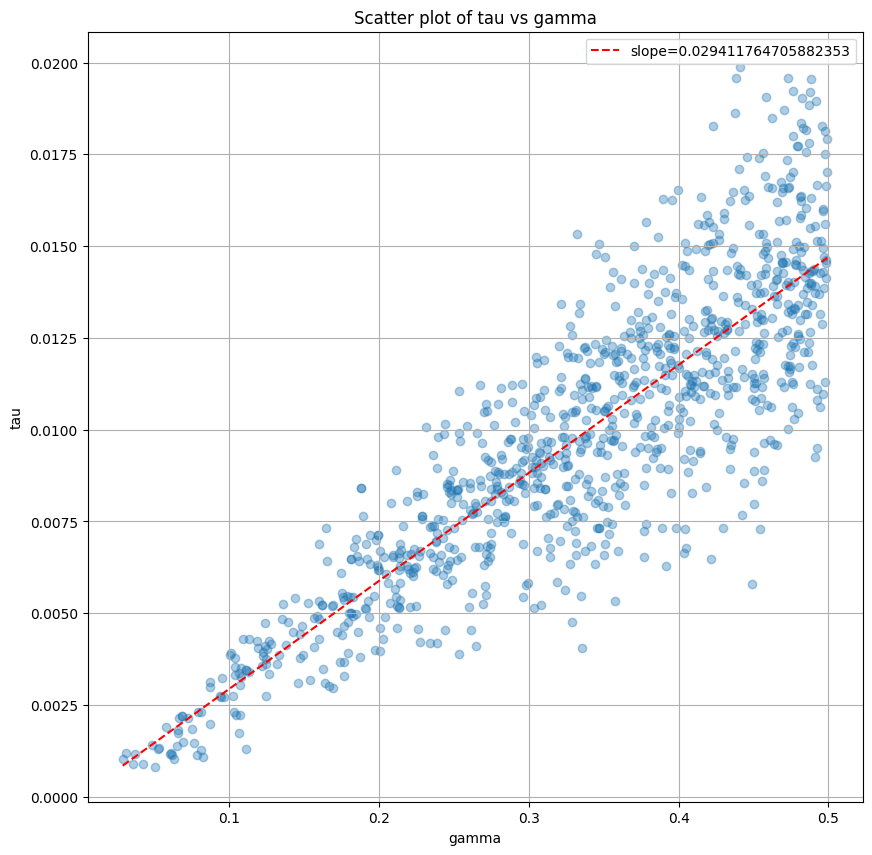

In [514]:
slope = 1/ratio

plt.figure(figsize=(10,10))
plt.scatter(data['gamma'], data['tau'], alpha=0.2)

x_vals = np.linspace(data['gamma'].min(), data['gamma'].max(), 100)
y_vals = slope * x_vals

plt.plot(x_vals, y_vals, color='red', linestyle='--', label=f'slope={slope}')

plt.xlabel('gamma')
plt.ylabel('tau')
plt.title('Scatter plot of tau vs gamma')
plt.legend()
plt.grid(True)
plt.show()